# Облакаааа

Этот ноутбук тренирует сверточную нейросеть для мульти-классовой/мульти-меточной классификации спутниковых снимков облаков.

**Что нужно рядом:**
- Папка с изображениями (например, `images/` или `train_images/`).
- CSV-файл с метками (например, `train.csv`). Поддерживаются два популярных формата:
  1) `image,label` — по одному классу на строку; для мультиметок — несколько строк на одно изображение.
  2) `image,labels` — строка с несколькими метками, разделёнными пробелом (например: `img_001.jpg,"open cell closed cell"`).

**Метрика качества:** Dice coefficient. Мы считаем macro/micro Dice и per-class Dice после порога вероятностей.

**Архитектура:** кастомная CNN в стиле «мини‑ResNet» со сверточными residual‑блоками, BatchNorm, Dropout и Global Average Pooling.

In [1]:
##############################
#            Config          #
##############################
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path

class Config:
    # Пути (относительно текущего каталога ноутбука)
    DATA_ROOT = Path('/content/drive/MyDrive/datasets/understanding_cloud_organization')
    CSV_PATH = DATA_ROOT / 'train.csv'            # путь к CSV
    IMAGES_DIR = DATA_ROOT / 'train_images'             # папка с изображениями
    TEST_IMEAGES_DIR = DATA_ROOT / 'test_images'
    IMAGE_COL = 'image'                       # имя колонки с именем файла изображения
    LABEL_COL_SINGLE = 'label'                # если по одной метке на строку
    LABEL_COL_MULTI = 'labels'                # если метки в одной строке через пробел
    LABELS_DELIM = ' '                        # разделитель для мульти‑меток
    IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

    # Тренировка
    IMG_SIZE = 256
    EPOCHS = 10
    BATCH_SIZE = 32
    LR = 3e-4
    WEIGHT_DECAY = 1e-4
    NUM_WORKERS = 5
    VAL_SPLIT = 0.15
    RANDOM_SEED = 42
    MIXED_PRECISION = True
    EARLY_STOPPING_PATIENCE = 2
    POS_WEIGHT = None

cfg = Config()
cfg

Mounted at /content/drive


In [2]:
%%capture
# Установка/импорт библиотек
!pip -q install torchmetrics --upgrade

import os, random, math, json
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
from collections import Counter, defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from torchmetrics.functional import f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

## Загрузка и подготовка данных


In [3]:
# ---- Kaggle Understanding Clouds: train.csv -> multi-label классификация ----
raw = pd.read_csv(cfg.CSV_PATH)
assert {'Image_Label','EncodedPixels'}.issubset(raw.columns), "Ожидаю колонки Image_Label и EncodedPixels"

# Разбиваем Image_Label на имя файла и класс (например: 'abc.jpg_Fish' -> 'abc.jpg','Fish')
tmp = raw.copy()
tmp[['image','label']] = tmp['Image_Label'].str.split('_', n=1, expand=True)

# Маска считается наличествующей, если EncodedPixels не NaN и не пустая строка
tmp['has_mask'] = tmp['EncodedPixels'].astype(str).str.strip().ne('nan') & tmp['EncodedPixels'].astype(str).str.strip().ne('')

# Классы из файла (Fish, Flower, Gravel, Sugar)
classes = sorted(tmp['label'].dropna().unique().tolist())
class_to_idx = {c:i for i,c in enumerate(classes)}
num_classes = len(classes)
multilabel = True  # это multi-label задача: у одной картинки может быть несколько типов облаков

print('Detected classes:', classes)
print('Multi-label task:', multilabel)

# Агрегируем по изображению -> multi-hot вектор по наличию маски хотя бы для одного объекта класса
records = []
for img, g in tmp.groupby('image'):
    vec = np.zeros(num_classes, dtype=np.float32)
    for _, r in g.iterrows():
        if r['has_mask']:
            vec[class_to_idx[r['label']]] = 1.0
    records.append({'image': img, 'target': vec})

data_df = pd.DataFrame(records)

assert 'image' in data_df.columns


Detected classes: ['Fish', 'Flower', 'Gravel', 'Sugar']
Multi-label task: True


In [4]:
train_df, val_df = train_test_split(
    data_df, test_size=cfg.VAL_SPLIT, random_state=cfg.RANDOM_SEED, shuffle=True
)

def count_targets(rows):
    if multilabel:
        s = np.zeros(num_classes)
        for v in rows:
            s += v
        return s.astype(int)
    else:
        return pd.Series(rows).value_counts().reindex(range(num_classes), fill_value=0).values

train_counts = count_targets(train_df['target'])
val_counts   = count_targets(val_df['target'])
print('Train class counts:', dict(zip(classes, train_counts)))
print('Val   class counts:', dict(zip(classes, val_counts)))

# Sampler для дисбаланса (опционально)
def make_sampler(df):
    if not multilabel:
        labels = df['target'].values
        class_sample_counts = np.bincount(labels, minlength=num_classes)
        weights = 1.0 / np.clip(class_sample_counts, 1, None)
        sample_weights = weights[labels]
        return WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    else:
        # Для мульти‑меток можно оценить вес как 1 / (1 + сумма весов меток)
        class_counts = train_counts + 1e-6
        inv = 1.0 / class_counts
        sample_weights = []
        for v in df['target'].values:
            w = (v * inv).sum()
            sample_weights.append(w)
        sample_weights = np.array(sample_weights)
        sample_weights = sample_weights / sample_weights.mean()
        return WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_sampler = make_sampler(train_df)

Train class counts: {'Fish': np.int64(2351), 'Flower': np.int64(2007), 'Gravel': np.int64(2496), 'Sugar': np.int64(3183)}
Val   class counts: {'Fish': np.int64(430), 'Flower': np.int64(358), 'Gravel': np.int64(443), 'Sugar': np.int64(568)}


In [5]:
class CloudDataset(Dataset):
    def __init__(self, df, images_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def _resolve_path(self, name):
        p = self.images_dir / name
        if p.exists():
            return p
        # пробуем найти с любым расширением
        base = Path(name).stem
        for ext in cfg.IMG_EXTS:
            cand = self.images_dir / f"{base}{ext}"
            if cand.exists():
                return cand
        raise FileNotFoundError(f"Не найден файл изображения для {name}")
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self._resolve_path(row[cfg.IMAGE_COL])
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        target = row['target']
        if multilabel:
            target = torch.tensor(target, dtype=torch.float32)
        else:
            target = torch.tensor(target, dtype=torch.long)
        return img, target

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(cfg.IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
val_tfms = transforms.Compose([
    transforms.Resize(int(cfg.IMG_SIZE*1.1)),
    transforms.CenterCrop(cfg.IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

train_ds = CloudDataset(train_df, cfg.IMAGES_DIR, transform=train_tfms)
val_ds   = CloudDataset(val_df,   cfg.IMAGES_DIR, transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, sampler=train_sampler,
                          num_workers=cfg.NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                          num_workers=cfg.NUM_WORKERS, pin_memory=True)
len(train_ds), len(val_ds)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


(4714, 832)

## Модель: кастомная CNN (Mini‑ResNet)
Делаем модель с residual блоками как в резнете, но руками

In [6]:
class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1, act=True):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, k, s, p, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True) if act else nn.Identity()
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.act(x)
        return x

class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.0):
        super().__init__()
        self.downsample = None
        if stride!=1 or in_ch!=out_ch:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        self.block = nn.Sequential(
            ConvBNAct(in_ch, out_ch, k=3, s=stride, p=1),
            nn.Dropout(p=dropout),
            ConvBNAct(out_ch, out_ch, k=3, s=1, p=1, act=False)
        )
        self.act = nn.ReLU(inplace=True)
    def forward(self, x):
        identity = x
        out = self.block(x)
        if self.downsample is not None:
            identity = self.downsample(x)
        out = out + identity
        out = self.act(out)
        return out

class MiniResNet(nn.Module):
    def __init__(self, num_classes, in_ch=3, width=32, dropout=0.2, multilabel=False):
        super().__init__()
        self.stem = nn.Sequential(
            ConvBNAct(in_ch, width, k=3, s=1, p=1),
            ConvBNAct(width, width, k=3, s=1, p=1)
        )
        self.layer1 = nn.Sequential(
            ResidualBlock(width,   width,   stride=1, dropout=dropout),
            ResidualBlock(width,   width,   stride=1, dropout=dropout),
        )
        self.layer2 = nn.Sequential(
            ResidualBlock(width,   width*2, stride=2, dropout=dropout),
            ResidualBlock(width*2, width*2, stride=1, dropout=dropout),
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(width*2, width*4, stride=2, dropout=dropout),
            ResidualBlock(width*4, width*4, stride=1, dropout=dropout),
        )
        self.layer4 = nn.Sequential(
            ResidualBlock(width*4, width*8, stride=2, dropout=dropout),
            ResidualBlock(width*8, width*8, stride=1, dropout=dropout),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Linear(width*8, num_classes)
        self.multilabel = multilabel
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x).flatten(1)
        logits = self.head(x)
        return logits

model = MiniResNet(num_classes=num_classes, multilabel=multilabel).to(device)
sum(p.numel() for p in model.parameters())

2805348

## Метрики и лоссы
- **Dice** для классификации после порогования (по умолчанию 0.5). Для multi‑label это F1 (macro/micro).
- Лосс: `BCEWithLogitsLoss` при multi‑label и `CrossEntropyLoss` при single‑label.

In [7]:
def sigmoid(x):
    return 1/(1+torch.exp(-x))

def dice_coef(y_true, y_pred, eps=1e-7, threshold=0.5, average='macro'):
    """Dice для классификации.
    y_true: (N,C) multi‑hot или (N,) индексы классов
    y_pred: логиты (N,C) или вероятности
    """
    if y_pred.dim()==1:
        y_pred = y_pred.unsqueeze(1)
    if not multilabel:
        # переведём в one‑hot для совместимости
        y_true_oh = F.one_hot(y_true, num_classes=num_classes).float()
        probs = F.softmax(y_pred, dim=1)
        y_hat = F.one_hot(probs.argmax(1), num_classes=num_classes).float()
    else:
        y_true_oh = y_true.float()
        probs = torch.sigmoid(y_pred)
        y_hat = (probs >= threshold).float()
    # считаем per‑class Dice
    dims = 0
    inter = (y_hat * y_true_oh).sum(dim=dims)
    sums  = y_hat.sum(dim=dims) + y_true_oh.sum(dim=dims)
    dice_per_class = (2*inter + eps) / (sums + eps)
    if average=='macro':
        return dice_per_class.mean().item(), dice_per_class.detach().cpu().numpy()
    elif average=='none':
        return dice_per_class.detach().cpu().numpy()
    else:
        # micro: сворачиваем по классам
        inter = inter.sum()
        sums = sums.sum()
        return ((2*inter + eps)/(sums + eps)).item(), dice_per_class.detach().cpu().numpy()

if multilabel:
    pos_weight = None
    if cfg.POS_WEIGHT is not None:
        pos_weight = torch.tensor(cfg.POS_WEIGHT, dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
else:
    criterion = nn.CrossEntropyLoss()


## Тренировка
Включены AMP, CosineAnnealingLR и Early Stopping (по лучшему **Dice**).

In [8]:
torch.manual_seed(cfg.RANDOM_SEED)
np.random.seed(cfg.RANDOM_SEED)
random.seed(cfg.RANDOM_SEED)

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS)
scaler = torch.cuda.amp.GradScaler(enabled=cfg.MIXED_PRECISION)

best_val = -1
patience = cfg.EARLY_STOPPING_PATIENCE
ckpt_path = 'best_model.pt'

def forward_pass(inputs, targets):
    with torch.cuda.amp.autocast(enabled=cfg.MIXED_PRECISION):
        logits = model(inputs)
        loss = criterion(logits, targets) if multilabel else criterion(logits, targets)
    return logits, loss

for epoch in range(1, cfg.EPOCHS+1):
    model.train()
    tr_loss = 0.0
    for imgs, targets in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits, loss = forward_pass(imgs, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        tr_loss += loss.item() * imgs.size(0)
    tr_loss /= len(train_loader.dataset)

    # Валидация
    model.eval()
    val_loss = 0.0
    all_logits = []
    all_targets = []
    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            logits, loss = forward_pass(imgs, targets)
            val_loss += loss.item() * imgs.size(0)
            all_logits.append(logits.cpu())
            all_targets.append(targets.cpu())
    val_loss /= len(val_loader.dataset)
    all_logits = torch.cat(all_logits)
    all_targets = torch.cat(all_targets)

    if multilabel:
        macro_dice, per_cls = dice_coef(all_targets, all_logits, average='macro')
    else:
        macro_dice, per_cls = dice_coef(all_targets, all_logits, average='macro')

    scheduler.step()
    print(f"Epoch {epoch:02d} | train_loss={tr_loss:.4f} val_loss={val_loss:.4f} val_macro_dice={macro_dice:.4f}")

    # Early Stopping по Dice
    if macro_dice > best_val:
        best_val = macro_dice
        torch.save({'model_state':model.state_dict(), 'classes':classes, 'multilabel':multilabel}, ckpt_path)
        patience = cfg.EARLY_STOPPING_PATIENCE
    else:
        patience -= 1
        if patience<=0:
            print('Early stopping triggered.')
            break


/tmp/ipython-input-1250745876.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.MIXED_PRECISION)
/tmp/ipython-input-1250745876.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.MIXED_PRECISION):


Epoch 01 | train_loss=0.5927 val_loss=0.7143 val_macro_dice=0.6323
Epoch 02 | train_loss=0.5577 val_loss=0.9354 val_macro_dice=0.5812
Epoch 03 | train_loss=0.5493 val_loss=0.6206 val_macro_dice=0.7292
Epoch 04 | train_loss=0.5446 val_loss=0.6674 val_macro_dice=0.6998
Epoch 05 | train_loss=0.5341 val_loss=0.6953 val_macro_dice=0.6766
Early stopping triggered.


## Оценка: Dice по классам, отчёт и матрица ошибок

In [9]:
# Загрузка лучшей модели
state = torch.load('best_model.pt', map_location='cpu')
model.load_state_dict(state['model_state'])
model.eval();

all_logits, all_targets = [], []
with torch.no_grad():
    for imgs, targets in val_loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        all_logits.append(logits.cpu())
        all_targets.append(targets)
all_logits = torch.cat(all_logits)
all_targets = torch.cat(all_targets)

macro_dice, per_class_dice = dice_coef(all_targets, all_logits, average='macro')
print(f"Validation Macro Dice: {macro_dice:.4f}")
for c,score in zip(classes, per_class_dice):
    print(f"{c:20s} Dice={score:.4f}")

if not multilabel:
    y_true = all_targets.numpy()
    y_pred = all_logits.softmax(1).argmax(1).numpy()
    print('\nClassification report:')
    print(classification_report(y_true, y_pred, target_names=classes, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation='nearest')
    plt.title('Confusion Matrix (Val)')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()
else:
    # для multi‑label дополнительно посчитаем micro‑Dice
    micro_dice, _ = dice_coef(all_targets, all_logits, average='micro')
    print(f"Micro Dice: {micro_dice:.4f}")


Validation Macro Dice: 0.7292
Fish                 Dice=0.7058
Flower               Dice=0.7140
Gravel               Dice=0.6890
Sugar                Dice=0.8080
Micro Dice: 0.7364


## Инференс на новых изображениях
Для multi‑label — выдаются вероятности и бинарные предсказания с порогом 0.5.

In [9]:
from glob import glob

INFER_DIR = cfg.TEST_IMEAGES_DIR
THRESH = 0.5

infer_tfms = val_tfms

def predict_dir(path: Path):
    files = []
    for ext in cfg.IMG_EXTS:
        files.extend(glob(str(path / f'*{ext}')))
    results = []
    with torch.no_grad():
        for f in files:
            img = Image.open(f).convert('RGB')
            t  = infer_tfms(img).unsqueeze(0).to(device)
            logits = model(t).cpu().squeeze(0)
            if multilabel:
                probs = torch.sigmoid(logits).numpy()
                pred  = (probs >= THRESH).astype(int)
            else:
                probs = torch.softmax(logits, dim=0).numpy()
                pred  = np.zeros_like(probs); pred[probs.argmax()] = 1
            results.append({'file': os.path.basename(f), 'probs': probs.tolist(), 'pred': pred.tolist()})
    return pd.DataFrame(results)

if INFER_DIR.exists():
    pred_df = predict_dir(INFER_DIR)
    display(pred_df.head())
else:
    print('Создайте папку', INFER_DIR, 'и поместите туда изображения для инференса.')


,file,probs,pred
0,bce3c05.jpg,"[0.5776898860931396, 0.4985487461090088, 0.537...","[1, 0, 1, 0]"
1,bc986b3.jpg,"[0.5752677321434021, 0.4989747703075409, 0.537...","[1, 0, 1, 0]"
2,bc1451e.jpg,"[0.5743070244789124, 0.4963718056678772, 0.539...","[1, 0, 1, 0]"
3,bd1522f.jpg,"[0.5734291672706604, 0.49598556756973267, 0.53...","[1, 0, 1, 0]"
4,bd108ae.jpg,"[0.575652003288269, 0.4991133511066437, 0.5394...","[1, 0, 1, 0]"


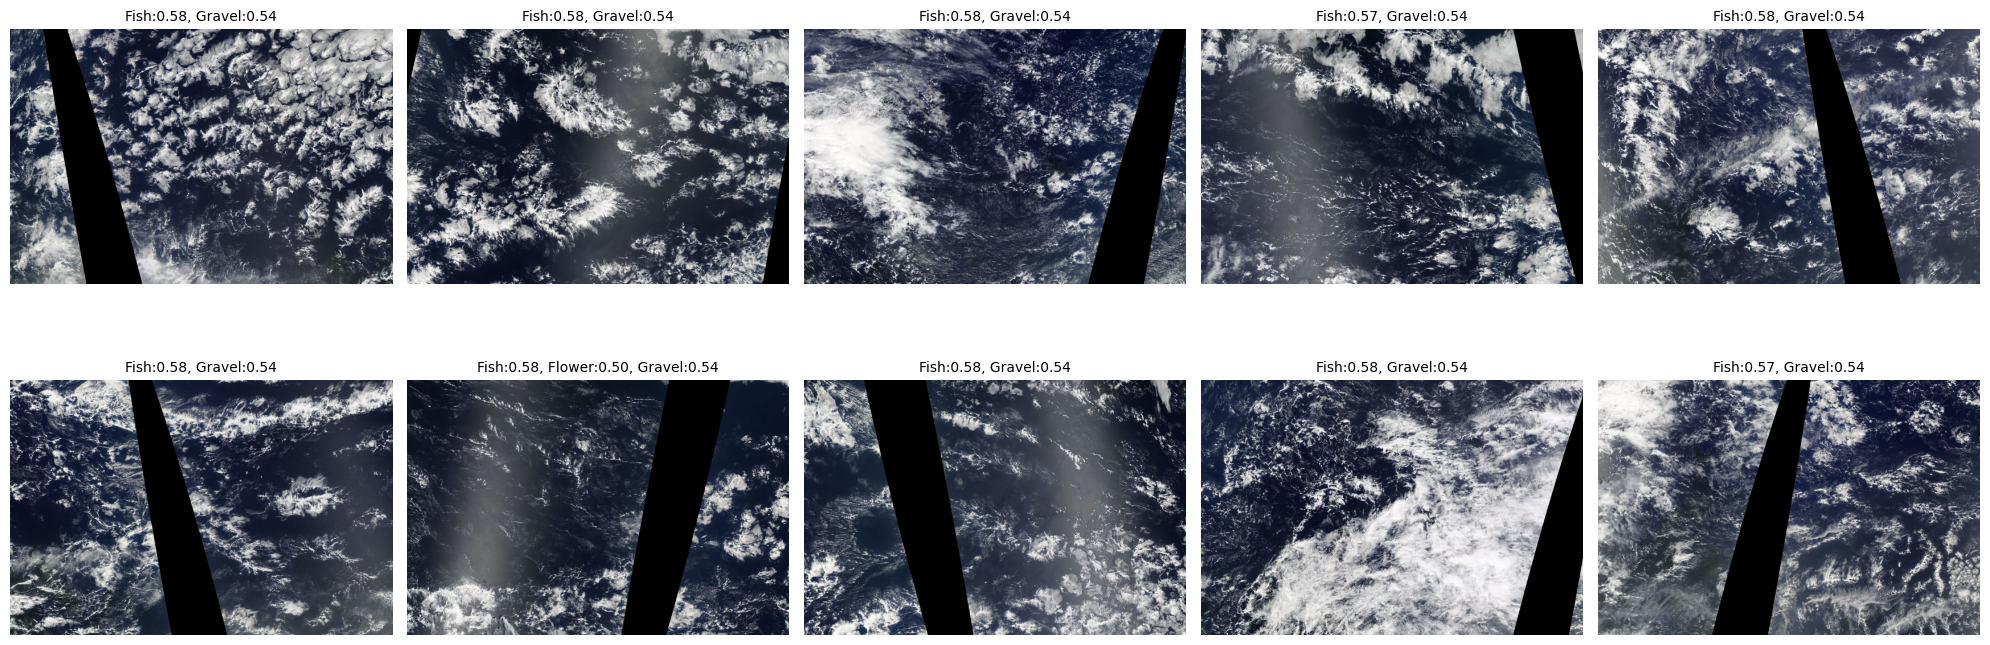

In [10]:
# Показ 10 случайных изображений с предсказаниями
import random, math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

N_SHOW = 10
THRESH_VIS = THRESH  # используем тот же порог, что и при инференсе
random.seed(0)

if not INFER_DIR.exists():
    print('Папка с инференсом не найдена:', INFER_DIR)
else:
    # Получаем предсказания, если ещё не считали
    try:
        pred_df
    except NameError:
        pred_df = predict_dir(INFER_DIR)

    # Случайная выборка файлов для показа
    files_all = pred_df['file'].tolist()
    if len(files_all) == 0:
        print('В папке нет изображений с подходящими расширениями:', cfg.IMG_EXTS)
    else:
        sample_files = random.sample(files_all, k=min(N_SHOW, len(files_all)))

        cols = 5
        rows = math.ceil(len(sample_files) / cols)
        plt.figure(figsize=(4*cols, 4*rows))

        for i, fname in enumerate(sample_files):
            fullpath = INFER_DIR / fname
            img = Image.open(fullpath).convert('RGB')

            row = pred_df[pred_df['file'] == fname].iloc[0]
            probs = np.array(row['probs'])

            if multilabel:
                # показываем классы с вероятностью >= порога; если ни одного — показываем top-1
                shown = [f"{cls}:{probs[j]:.2f}" for j, cls in enumerate(classes) if probs[j] >= THRESH_VIS]
                if not shown:
                    j = probs.argmax()
                    shown = [f"{classes[j]}:{probs[j]:.2f}"]
                title = ", ".join(shown)
            else:
                # single-label: покажем top-3 для наглядности
                topk = np.argsort(-probs)[:3]
                title = " | ".join([f"{classes[j]}:{probs[j]:.2f}" for j in topk])

            ax = plt.subplot(rows, cols, i+1)
            ax.imshow(img)
            ax.axis('off')
            ax.set_title(title, fontsize=10)

        plt.tight_layout()
        plt.show()


## Итого
Обучен миниатюрный аналог resNet вручную
Дайс в районе 0.7 - потому что эпох обучения было маловато, и толеранс выставлен очень низкий. На постоянно доступном ресурсе ГПУ можно было бы запустить обучение подольше, но в облаке получилось пока так.

Думаю, если взять готовую резнет из торча и поучить, будет еще выше Dice.

Потенциальный TODO: если нам нужен один класс на изображении, надо кропнуть вход и сделать датасет побольше. Пока этого не сделано
